<a href="https://colab.research.google.com/github/Muhammad-AHMAD07/ML_Lab/blob/main/ML(Lab_3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Manual Linear Regression

Data Set Creation

In [ ]:
import numpy as np

size=np.array([5,7,10,12,15,20,25,30,35,40,45,50])
price=np.array([10000,20000,30000,40000,50000,60000,70000,80000,90000,100000,110000,120000])

print(size)
print(price)

[ 5  7 10 12 15 20 25 30 35 40 45 50]
[ 10000  20000  30000  40000  50000  60000  70000  80000  90000 100000
 110000 120000]


Contraints Def

In [ ]:
m = 0
b = 0
learning_rate = 0.001
epochs = 1000
n = len(size)

Calculating Slope and Intercept

In [ ]:
for i in range(epochs):

    price_pred = m * size + b


    dm = (-2/n) * np.sum(size * (price - price_pred))
    db = (-2/n) * np.sum(price - price_pred)


    m = m - learning_rate * dm
    b = b - learning_rate * db

print("Final slope (m):", m)
print("Final intercept (b):", b)




Final slope (m): 2460.704709220786
Final intercept (b): 3439.6557206391976


Plotting

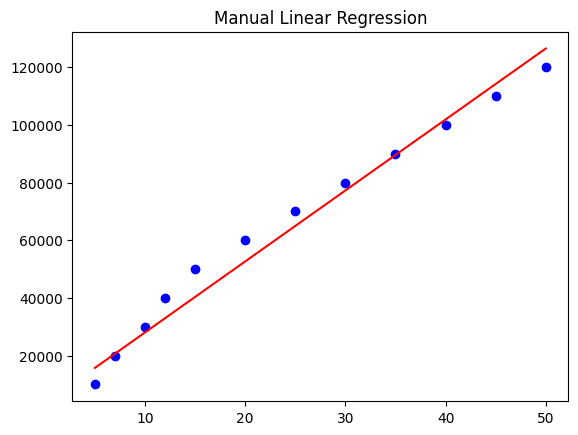

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(size,price, color='blue')
plt.plot(size, m * size + b, color='red')
plt.title("Manual Linear Regression")
plt.show()

Error Of Manual linear Regression

In [ ]:
for i in range(n):
  MSE=(1/n)*np.sum(m*size+b-price)**2
  R_Squared=1-(MSE/np.sum((price-np.mean(price))**2))

print("Mean Square Error ",MSE)
print("R Squared Value ",R_Squared*100,"%")


Mean Square Error  19448758.732960694
R Squared Value  99.86399469417509 %


Linear Regression using Libraries

Importing Libraries

In [ ]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
data = pd.read_csv("/content/data.csv")
print("First 5 rows of the dataset:")
print(data.head())

First 5 rows of the dataset:
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_ren

In [ ]:
X = data[['sqft_living']]
y = data['price']

In [ ]:
print("\nMissing values in the dataset:")
print(data.isnull().sum())


Missing values in the dataset:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


splitting Dataset

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

Applying Linear Model

In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

Checking Value of m and c

In [ ]:
print(" Slope (β1):", model.coef_)
print("Intercept (β0):", model.intercept_)

 Slope (β1): [267.22365824]
Intercept (β0): -26048.2093954297


Predicting value of Testing Data

In [ ]:
y_pred = model.predict(X_test)
comparison=pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
print(comparison.head())


      Actual      Predicted
0   544000.0  364098.331631
1        0.0  508399.107079
2  1712500.0  759589.345822
3   365000.0  561843.838727
4   275000.0  433576.482773


Error

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)
print("\nModel Evaluation Metrics:")
print("Mean Squared Error (MSE):", mse)
print("R-squared (R²):", r2)



Model Evaluation Metrics:
Mean Squared Error (MSE): 990204087727.1417
R-squared (R²): 0.029065410341410414


Plotting

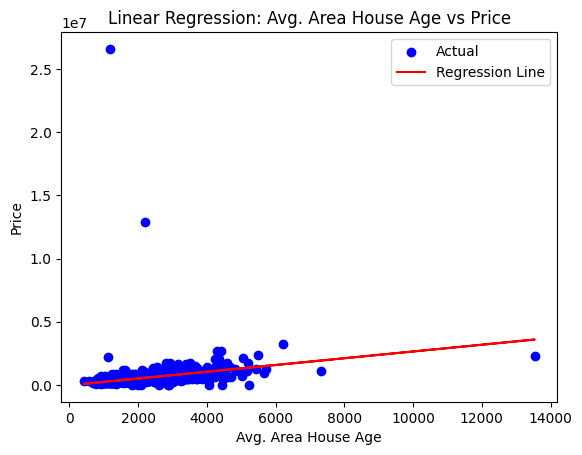

In [ ]:
plt.scatter(X_test,y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred,color='red', label='Regression Line')
plt.xlabel("Avg. Area House Age")
plt.ylabel("Price")
plt.title("Linear Regression: Avg. Area House Age vs Price")
plt.legend()
plt.show()